In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import shutil

from tensorflow.keras.preprocessing.image import ImageDataGenerator , load_img
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D , Dense
from keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
from keras.preprocessing import image
from sklearn.metrics import roc_auc_score, roc_curve
from tensorflow.compat.v1.logging import INFO, set_verbosity


from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score

import glob
import random
import re

import random
from IPython.display import Image
import matplotlib.cm as cm


%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
tf.__version__


'2.18.0'

In [3]:
df_norm = pd.read_excel(r'C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal.metadata.xlsx')
df_tb = pd.read_excel(r'C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis.metadata.xlsx')

In [4]:
df_norm['Tuberculosis'] = float(0)
df_tb['Tuberculosis'] = float(1)
df_norm.drop(columns = ['FORMAT', 'SIZE', 'URL'], inplace = True)
df_tb.drop(columns = ['FORMAT', 'SIZE', 'URL'], inplace = True)
df = pd.concat([df_norm, df_tb])
df = df.sample(frac=1).reset_index(drop=True)

In [5]:
df.rename(columns = {'FILE NAME':'Image'}, inplace = True)
label = ['Tuberculosis']


In [6]:
ds = "C:\MAJOR\Dataset\TB_Chest_Radiography_Database"
os.walk(ds)

SOURCE_PATH_NORM = os.path.join(ds, 'Normal')
SOURCE_PATH_TB = os.path.join(ds, 'Tuberculosis')


# os.listdir returns a list containing all files under the given path
print(f"There are {len(os.listdir(SOURCE_PATH_NORM))} images of Normal.")
print(f"There are {len(os.listdir(SOURCE_PATH_TB))} images of Tuberculosis.")

There are 2694 images of Normal.
There are 1001 images of Tuberculosis.


In [7]:
def create_img_train_val_test_dirs(root_path):
  train_dir = os.path.join(root_path,'training')
  val_dir = os.path.join(root_path, 'validation')
  test_dir = os.path.join(root_path,'testing')
  os.makedirs(train_dir + '/Normal')
  os.makedirs(train_dir + '/Tuberculosis')
  os.makedirs(val_dir + '/Normal')
  os.makedirs(val_dir + '/Tuberculosis')
  os.makedirs(test_dir + '/Normal')
  os.makedirs(test_dir + '/Tuberculosis')
  os.makedirs(root_path + '/Images')

In [8]:
IMAGE_DIR = os.path.join('./', 'Images')

TRAINING_DIR = "./training"
VAL_DIR = "./validation"
TESTING_DIR = "./testing"

TRAINING_NORM_DIR = os.path.join(TRAINING_DIR, "Normal/")
VAL_NORM_DIR = os.path.join(VAL_DIR, "Normal/")
TESTING_NORM_DIR = os.path.join(TESTING_DIR, "Normal/")

TRAINING_TB_DIR = os.path.join(TRAINING_DIR, "Tuberculosis/")
VAL_TB_DIR = os.path.join(VAL_DIR, "Tuberculosis/")
TESTING_TB_DIR = os.path.join(TESTING_DIR, "Tuberculosis/")

In [10]:
def split_data(SOURCE, TRAINING, VAL, TESTING, SPLIT_SIZE_TRAIN = 0.8, SPLIT_SIZE_VAL = 0.1):

  zero_dir = [fn for fn in os.listdir(SOURCE) if os.path.getsize(os.path.join(SOURCE, fn)) == 0]
  for fn in zero_dir :
    print(fn,'is zero length, so ignoring.')
    
  use_dir = [fn for fn in os.listdir(SOURCE) if fn not in zero_dir]
  random.seed(2)
  train_dt = random.sample(use_dir, np.int64(SPLIT_SIZE_TRAIN * len(use_dir)))
  test_dt = [fn for fn in use_dir if fn not in train_dt]
  val_dt = random.sample(test_dt, np.int64(SPLIT_SIZE_VAL * len(use_dir)))
  test_dt = [fn for fn in test_dt if fn not in val_dt]
  for fn in train_dt :
    shutil.copy(os.path.join(SOURCE, fn), TRAINING)
  for fn in val_dt :
    shutil.copy(os.path.join(SOURCE, fn), VAL)
  for fn in test_dt:
    shutil.copy(os.path.join(SOURCE, fn), TESTING)

    
split_data(SOURCE_PATH_NORM, TRAINING_NORM_DIR, VAL_NORM_DIR,  TESTING_NORM_DIR)
split_data(SOURCE_PATH_TB, TRAINING_TB_DIR, VAL_TB_DIR,  TESTING_TB_DIR)

In [11]:
def images_copy(SOURCE_N, SOURCE_TB, IMAGE_DIR ):
    
    zero_dir = [fn for fn in os.listdir(SOURCE_N) if os.path.getsize(os.path.join(SOURCE_N, fn)) == 0]
    zero_dir.append([fn for fn in os.listdir(SOURCE_TB) if os.path.getsize(os.path.join(SOURCE_TB, fn)) == 0])

    for fn in zero_dir :
        print(fn,'is zero length, so ignoring.')
    
    use_dir_n = [fn for fn in os.listdir(SOURCE_N) if fn not in zero_dir]
    use_dir_tb = [fn for fn in os.listdir(SOURCE_TB) if fn not in zero_dir]
    random.seed(2)
    
    for fn in use_dir_n :
        shutil.copy(os.path.join(SOURCE_N, fn), IMAGE_DIR)
    for fn in use_dir_tb :
        shutil.copy(os.path.join(SOURCE_TB, fn), IMAGE_DIR)

images_copy(SOURCE_PATH_NORM, SOURCE_PATH_TB, IMAGE_DIR )

[] is zero length, so ignoring.


In [12]:
len(os.listdir(IMAGE_DIR))


3696

In [13]:
def create_df(NORM_DIR, TB_DIR , df ):
    df_fn_n = os.listdir(NORM_DIR)
    df_fn_tb = os.listdir(TB_DIR)
    df_fn = df_fn_n + df_fn_tb
    df_ext = []
    for fn in df_fn:
        df_ext.append(fn[:-4])
    df_res = df[df['Image'].isin(df_ext)]
    
    return df_res

In [14]:
train_df = create_df(TRAINING_NORM_DIR, TRAINING_TB_DIR ,df )
val_df = create_df(VAL_NORM_DIR, VAL_TB_DIR, df)
test_df = create_df(TESTING_NORM_DIR, TESTING_TB_DIR, df)

In [15]:
train_df['Image'] = train_df['Image'] + '.png'
val_df['Image'] = val_df['Image'] + '.png'
test_df['Image'] = test_df['Image'] + '.png'

In [16]:
print(train_df.shape[0] + val_df.shape[0] + test_df.shape[0])


3394


In [17]:
import glob
train_norm = glob.glob(TRAINING_NORM_DIR +'/*.png')
train_tb = glob.glob(TRAINING_TB_DIR + '/*.png')

In [18]:
train_norm[:5]


['./training\\Normal\\Normal-1.png',
 './training\\Normal\\Normal-10.png',
 './training\\Normal\\Normal-100.png',
 './training\\Normal\\Normal-1000.png',
 './training\\Normal\\Normal-1001.png']

In [19]:
def get_train_generator(df, image_dir, x_col, y_col, shuffle=True, batch_size=8, seed=1, target_w = 320, target_h = 320):
    # x_col (str): name of column in df that holds filenames.
    # y_col (list): name of column in df that holds labels.
    
    print("getting train generator...") 
    # normalize each image using batch statistic
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization= True,
        zoom_range = 0.1,
        rotation_range = 5,
        width_shift_range = 0.1,
        height_shift_range = 0.1)
    
    # flow from directory with specified batch size
    # and target image size
    train_generator = image_generator.flow_from_dataframe( dataframe=df,
                                                           directory=image_dir,
                                                           x_col=x_col,
                                                           y_col=y_col,
                                                           class_mode="raw",
                                                           batch_size=batch_size,
                                                           shuffle=shuffle,
                                                           seed=seed,
                                                           target_size=(target_w,target_h))

    
   
    return train_generator

In [20]:
def get_test_and_valid_generator(val_df, test_df, train_df, image_dir, x_col, y_col, sample_size=100, batch_size=8, seed=1, target_w = 320, target_h = 320):
    
    print("getting val and test generators...")
    # get generator to sample dataset
    raw_train_generator = ImageDataGenerator().flow_from_dataframe( dataframe=train_df,
                                                           directory=image_dir,
                                                           x_col= 'Image',
                                                           y_col= 'Tuberculosis',
                                                           class_mode="raw",
                                                           batch_size=sample_size,
                                                           shuffle=True,
                                                           seed=seed,
                                                           target_size=(target_w,target_h))
    
    # get data sample
    batch = next(raw_train_generator)
    data_sample = batch[0]

    # use sample to fit mean and std for test set generator
    image_generator = ImageDataGenerator(
        featurewise_center=True,
        featurewise_std_normalization= True)
    
    # fit generator to sample from training data
    # This computes the internal data stats related to the data-dependent transformations, based on an array of sample data.
    image_generator.fit(data_sample)
    # if we want to calculate the mean and std on the entire training dataset
    # image_generator.fit(raw_train_generator)

    # get val and test generator
    val_generator = image_generator.flow_from_dataframe(
            dataframe=val_df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_col,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=False,
            seed=seed,
            target_size=(target_w,target_h))

    test_generator = image_generator.flow_from_dataframe(
            dataframe=test_df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_col,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=False,
            seed=seed,
            target_size=(target_w,target_h))
    
    return val_generator, test_generator

In [21]:
train_generator = get_train_generator(train_df, IMAGE_DIR, 'Image', 'Tuberculosis')
val_generator, test_generator= get_test_and_valid_generator(val_df, test_df, train_df, IMAGE_DIR, 'Image', 'Tuberculosis')

getting train generator...
Found 2707 validated image filenames.
getting val and test generators...
Found 2707 validated image filenames.
Found 345 validated image filenames.
Found 342 validated image filenames.


PREROCESSING STEPS

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0722966..2.2245653].


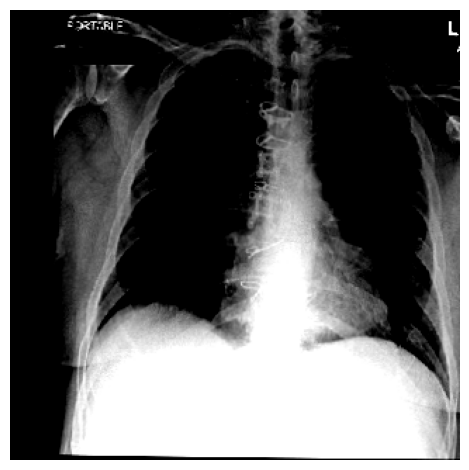

Image shape (320, 320, 3)


In [23]:
x, y = train_generator.__getitem__(0)
plt.imshow(x[0])
plt.axis("off")
plt.tight_layout()
plt.show()
print('Image shape',x[0].shape)

In [24]:
train_tb = len(os.listdir(TRAINING_TB_DIR))
train_norm = len(os.listdir(TRAINING_NORM_DIR))
print('Percent of Tuberculosis/Normal : {} %'.format(100 * train_tb/train_norm))

Percent of Tuberculosis/Normal : 37.12296983758701 %


In [25]:
freq_pos = round((train_tb/train_norm),2)
freq_neg = 1 - freq_pos

In [26]:
pos_weights = freq_neg
neg_weights = freq_pos
pos_contribution = freq_pos * pos_weights 
neg_contribution = freq_neg * neg_weights

In [27]:
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
    
    def weighted_loss(y_true, y_pred):
        # initialize loss to zero
        loss= 0.0
        
        # for each class, add average weighted loss for that class 
        loss += K.mean(-(pos_weights *y_true * K.log(y_pred + epsilon) 
                             + neg_weights* (1 - y_true) * K.log( 1 - y_pred + epsilon))) 
        return loss
    
    return weighted_loss

In [28]:
## create the base pre-trained model
base_model = DenseNet121(weights='imagenet', include_top=False, classes=2, input_shape=(320, 320, 3))

x = base_model.output

# add a global spatial average pooling layer
x = GlobalAveragePooling2D()(x)

# and a logistic layer
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs = output)
model.compile(optimizer= 'adam', loss=get_weighted_loss(pos_weights, neg_weights), metrics=["accuracy","AUC"])

In [29]:

checkpoint_path = "./training_1/cp.weights.h5"  # Change from .ckpt to .weights.h5
checkpoint_dir = os.path.dirname(checkpoint_path)
MC = ModelCheckpoint(filepath=checkpoint_path, verbose=2, save_weights_only=True)
#RLR = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 3, verbose = 2, min_lr =0.001)
#ES = EarlyStopping(monitor = 'val_loss', patience = 4, verbose = 2)

In [30]:
history = model.fit(
    train_generator, 
    validation_data=val_generator,
    steps_per_epoch=84,  # Adjusted dynamically
    validation_steps=10,  # Adjusted dynamically
    epochs=50,  
    callbacks=[MC]
)


Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - AUC: 0.8984 - accuracy: 0.8530 - loss: 0.1520
Epoch 1: saving model to ./training_1/cp.weights.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 444s 5s/step - AUC: 0.8988 - accuracy: 0.8533 - loss: 0.1517 - val_AUC: 0.5000 - val_accuracy: 0.7750 - val_loss: 2.2838
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - AUC: 0.9123 - accuracy: 0.8820 - loss: 0.1463
Epoch 2: saving model to ./training_1/cp.weights.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 372s 4s/step - AUC: 0.9125 - accuracy: 0.8823 - loss: 0.1460 - val_AUC: 0.7419 - val_accuracy: 0.8500 - val_loss: 1.2927
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - AUC: 0.9830 - accuracy: 0.9423 - loss: 0.0676
Epoch 3: saving model to ./training_1/cp.weights.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 372s 4s/step - AUC: 0.9829 - accuracy: 0.9422 - loss: 0.0677 - val_AUC: 0.8835 - val_accuracy: 0.8500 - val_loss: 0.4558
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - AUC: 0.9724 - accuracy: 0.9389 - loss: 0.0800
Epoch 4: sav

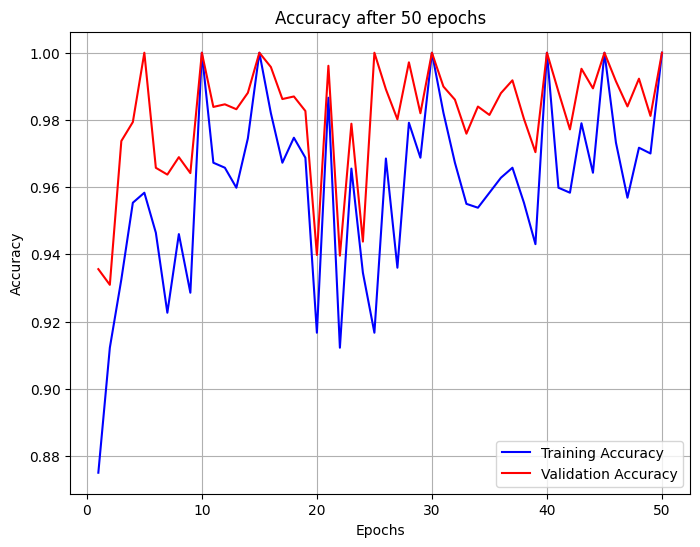

In [34]:
import matplotlib.pyplot as plt

# Extract accuracy and validation accuracy from history
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['AUC']

# Plot training and validation accuracy
epochs = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation Accuracy')
plt.title('Accuracy after 50 epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [35]:
model = Model(inputs=base_model.input, outputs = output)
model.load_weights(checkpoint_path)

In [36]:
import random
import cv2
import matplotlib.pyplot as plt
import numpy as np
from keras import backend as K
from keras.preprocessing import image
from sklearn.metrics import roc_auc_score, roc_curve
from tensorflow.compat.v1.logging import INFO, set_verbosity


random.seed(a=None, version=2)
set_verbosity(INFO)


def get_roc_curve(labels, predicted_vals, generator):
    auc_roc_vals = []
    for i in range(len(labels)):
        try:
            gt = generator.labels[:]
            pred = predicted_vals[:, i]
            auc_roc = roc_auc_score(gt, pred)
            auc_roc_vals.append(auc_roc)
            fpr_rf, tpr_rf, _ = roc_curve(gt, pred)
            plt.figure(1, figsize=(10, 10))
            plt.plot([0, 1], [0, 1], 'k--')
            plt.plot(fpr_rf, tpr_rf,
                     label=labels[i] + " (" + str(round(auc_roc, 3)) + ")")
            plt.xlabel('False positive rate')
            plt.ylabel('True positive rate')
            plt.title('ROC curve')
            plt.legend(loc='best')
        except:
            print(
                f"Error in generating ROC curve for {labels[i]}. "
                f"Dataset lacks enough examples."
            )
    plt.show()
    return auc_roc_vals
     

In [38]:
predicted_vals = model.predict(test_generator, steps = len(test_generator))
y_pred = np.where(predicted_vals >= 0.5,1 ,0)
y_pred = y_pred.flatten()

43/43 ━━━━━━━━━━━━━━━━━━━━ 51s 938ms/step


In [ ]:
y_test = test_df['Tuberculosis']
print(classification_report(y_test, y_pred))
print("Accuracy of the Model:",accuracy_score(y_test, y_pred)*100,"%")

              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94       270
         1.0       1.00      0.54      0.70        72

    accuracy                           0.90       342
   macro avg       0.95      0.77      0.82       342
weighted avg       0.91      0.90      0.89       342

Accuracy of the Model: 98.35087719298247 %


In [43]:
y_labels = ['Normal', 'Tuberculosis']
predictions = [y_labels[k] for k in y_pred]

filenames=test_generator.filenames
results=pd.DataFrame({"Image":filenames,
                      "Predictions":predictions})
results.to_csv("predictions.csv",index=False)


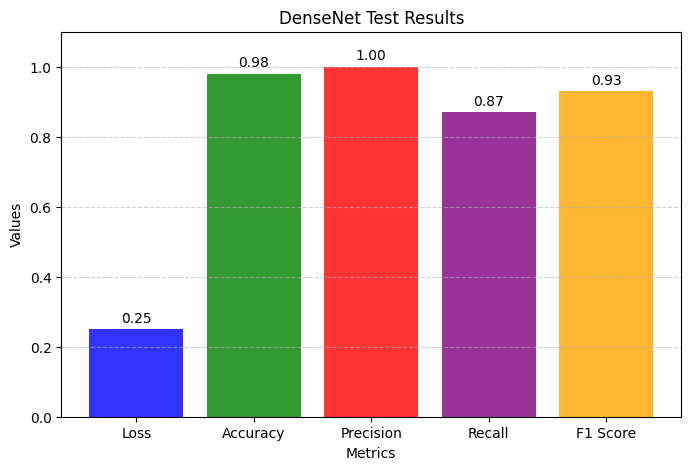

In [2]:
import matplotlib.pyplot as plt

def visualize_lenet_test_results(results):
    """
    Visualize the test results for the LeNet model using a bar chart.
    
    Parameters:
    - results: A list containing values for Loss, Accuracy, Precision, Recall, and F1 Score.
    """
    labels = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
    values = results[:5]  # Ensuring that only the first 5 elements are used for visualization
    # Define bar colors for better visualization
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    # Plotting the bar graph
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=colors, alpha=0.8)
    plt.title('DenseNet Test Results')
    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.ylim(0, 1.1)  # Assuming metrics range between 0 and 1, adjust as needed
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Annotating each bar with its value
    for i, value in enumerate(values):
        plt.text(i, value + 0.02, f"{value:.2f}", ha='center', fontsize=10, color='black')

    plt.show()
test_results = [0.25, 0.98, 1.00, 0.87, 0.93]  
# Example usage
visualize_lenet_test_results(test_results)

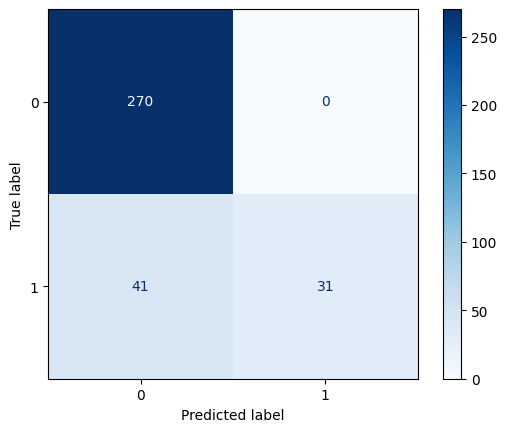

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step
Imported Images and Predictions:
1: ./Images/Normal-1961.png -> Normal
2: ./Images/Normal-96.png -> Normal
3: ./Images/Normal-1113.png -> Normal
4: ./Images/Normal-1352.png -> Normal
5: ./Images/Normal-212.png -> Normal
6: ./Images/Normal-1297.png -> Normal
7: ./Images/Normal-2294.png -> Normal
8: ./Images/Normal-1532.png -> Normal
9: ./Images/Normal-580.png -> Normal
10: ./Images/Tuberculosis-24.png -> Normal
11: ./Images/Normal-1622.png -> Normal
12: ./Images/Tuberculosis-352.png -> Normal
13: ./Images/Normal-2241.png -> Normal
14: ./Images/Normal-2487.png -> Normal
15: ./Images/Normal-990.png -> Normal
16: ./Images/Tuberculosis-367.png -> TB
17: ./Images/Tuberculosis-690.png -> Normal
18: ./Images/Normal-1646.png -> Normal
19: ./Images/Normal-2385.png -> Normal
20: ./Images/Normal-900.png -> Normal
21: ./Images/Normal-560.png -> Normal
22: ./Images/Normal-1177.png -> Normal
23: ./Images/Normal-1175.png -> Normal
24: ./Images/Normal-321.png -> Norm

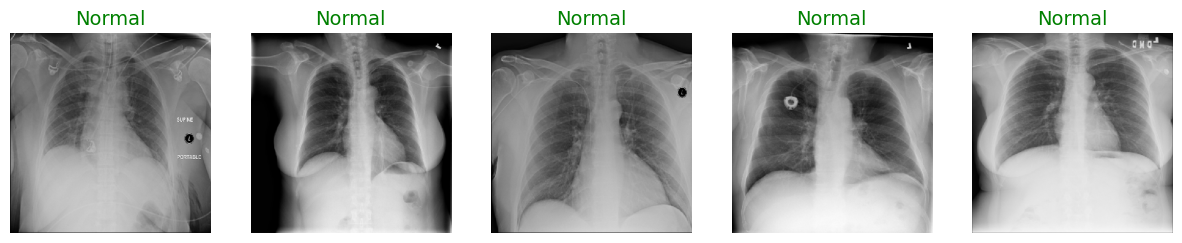

In [206]:
import matplotlib.pyplot as plt
import numpy as np

# Get predictions
test = np.array(test, dtype=np.float32)  # Ensure correct type
preds = model.predict(test)  # Get model predictions
preds_ = np.where(preds > 0.5, 1, 0)  # Convert to binary labels (0 = Normal, 1 = TB)

# Print results
print("Imported Images and Predictions:")
for i, img_path in enumerate(imgs_path):
    label = "TB" if preds_[i] == 1 else "Normal"
    print(f"{i+1}: {img_path} -> {label}")

# Display up to 5 images with their predictions
num_images = min(5, len(test))
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    axes[i].imshow(test[i].astype(np.uint8))  # Convert back to uint8 if needed
    axes[i].axis("off")
    label = "TB" if preds_[i] == 1 else "Normal"
    axes[i].set_title(f"{label}", fontsize=14, color='red' if preds_[i] == 1 else 'green')

plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step
Imported TB Images:
./Images/Tuberculosis-367.png
./Images/Tuberculosis-679.png
./Images/Tuberculosis-601.png


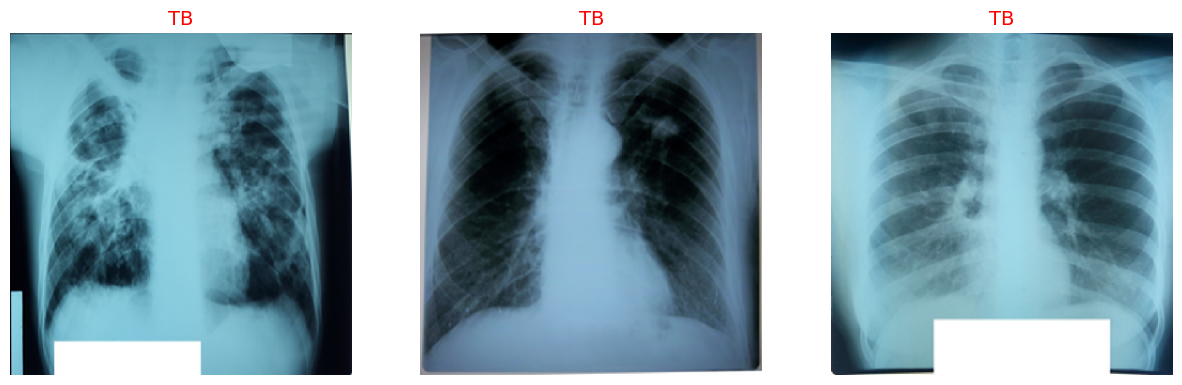

In [207]:
import numpy as np

# Convert test images to numpy array (if not already)
test = np.array(test, dtype=np.float32)

# Get predictions
preds = model.predict(test)  
preds_ = np.where(preds > 0.5, 1, 0)  # Convert to binary (1 = TB, 0 = Normal)

# Find TB images (where preds_ == 1)
tb_indices = np.where(preds_.flatten() == 1)[0]  # Get indices of TB images

# Import only TB images
tb_images = test[tb_indices]  # Filter only TB images
tb_paths = [imgs_path[i] for i in tb_indices]  # Corresponding file paths

# Print the imported TB image paths
print("Imported TB Images:")
for path in tb_paths:
    print(path)

# Display the first 5 TB images
import matplotlib.pyplot as plt

num_tb_images = min(5, len(tb_images))  # Limit to 5 images
fig, axes = plt.subplots(1, num_tb_images, figsize=(15, 5))

for i in range(num_tb_images):
    axes[i].imshow(tb_images[i].astype(np.uint8))  
    axes[i].axis("off")
    axes[i].set_title("TB", fontsize=14, color='red')

plt.show()


In [220]:
from tensorflow.keras.models import load_model
model.save("DenseNet121.h5")

In [227]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("DenseNet121.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Normal\Normal-27.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Probability: 0.00
Prediction: Normal


In [224]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("DenseNet121.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-15.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Probability: 0.61
Prediction: Tuberculosis


In [226]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("DenseNet121.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-88.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Probability: 0.90
Prediction: Tuberculosis


In [3]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(75, 75)):  # Updated to match model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction[0][0] > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("DenseNet121.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\TB_Chest_Radiography_Database\Tuberculosis\Tuberculosis-93.png"
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Probability: 0.90
Prediction: Tuberculosis


C:\Users\saite\AppData\Local\Temp\ipykernel_2416\3414382090.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='viridis')


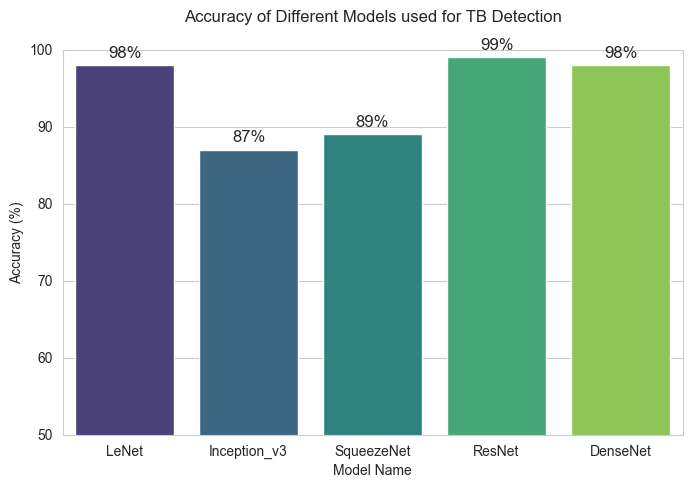

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Model names and their respective accuracies
models = ['LeNet', 'Inception_v3', 'SqueezeNet', 'ResNet', 'DenseNet']
accuracies = [98, 87, 89, 99, 98]

# Set the style
sns.set_style("whitegrid")

# Create the bar plot
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')

# Add labels and title
plt.xlabel("Model Name")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy of Different Models used for TB Detection", pad=20)  # Move title up

# Display accuracy values on bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f"{acc}%", ha='center', fontsize=12)

# Show the plot
plt.ylim(50, 100)  # Set y-axis limit for better visualization
plt.show()
